# Predictive Maintenance: От детекции аномалий к расчету Health Index подшипников

## 1. Контекст задачи и профиль данных
Анализ деградации подшипников на основе **IMS Bearing Dataset** (эксперименты *run-to-failure*).

**Техническая спецификация данных:**
* **Сэмплирование:** 1 файл = 1 секунда записи (20 480 измерений на частоте 20 кГц).
* **Каналы:** 4 независимых датчика вибрации (B1, B2, B3, B4).
* **Хронология:** Имя каждого файла является временной меткой (Timestamp) снятия показаний. Дискретные интервалы между записями могут варьироваться.

In [6]:
# Сторонние библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.fft import fft, fftfreq

# Настройки отображения pandas (удобно для инженерии)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.5f}')

# --- КОНФИГУРАЦИЯ (Configuration) ---
DATA_DIR = Path('../data/2nd_test')
SAMPLE_FILE = DATA_DIR / '2004.02.12.10.32.39'
BEARING_NAMES = ['B1', 'B2', 'B3', 'B4']

# --- ЗАГРУЗКА ДАННЫХ (Data Loading) ---
# Читаем один файл для оценки структуры
df_sample = pd.read_csv(
    SAMPLE_FILE,
    sep='\t',
    header=None,
    names=BEARING_NAMES
)

# Проверка: смотрим на базовые статистики
display(df_sample.info())
display(df_sample.sample(5))
display(df_sample.describe()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20480 entries, 0 to 20479
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   B1      20480 non-null  float64
 1   B2      20480 non-null  float64
 2   B3      20480 non-null  float64
 3   B4      20480 non-null  float64
dtypes: float64(4)
memory usage: 640.1 KB


None

,B1,B2,B3,B4
9995,-0.07300,-0.10700,-0.07300,0.01500
8110,-0.03700,0.08300,-0.06300,-0.00700
14873,0.03400,0.02400,-0.02000,-0.02900
8480,0.02900,-0.04200,0.06800,0.02900
15467,-0.00700,-0.14400,0.02000,-0.03700


,B1,B2,B3,B4
count,20480.00000,20480.00000,20480.00000,20480.00000
mean,-0.01020,-0.01269,-0.01454,-0.01003
std,0.07348,0.09006,0.10844,0.05317
min,-0.38600,-0.51300,-0.91100,-0.26400
25%,-0.05900,-0.07300,-0.08100,-0.04600
50%,-0.01000,-0.01500,-0.01500,-0.01000
75%,0.03700,0.04600,0.05100,0.02700
max,0.45400,0.46400,1.02300,0.19300


## 2. Спектральный анализ вибрации (FFT)
Сигнал во временной области сложно анализировать на предмет износа. Переход в частотную область с помощью Быстрого преобразования Фурье (FFT) позволяет выделить гармоники, соответствующие физическим дефектам (например, частоту перекатывания шариков по наружному кольцу).

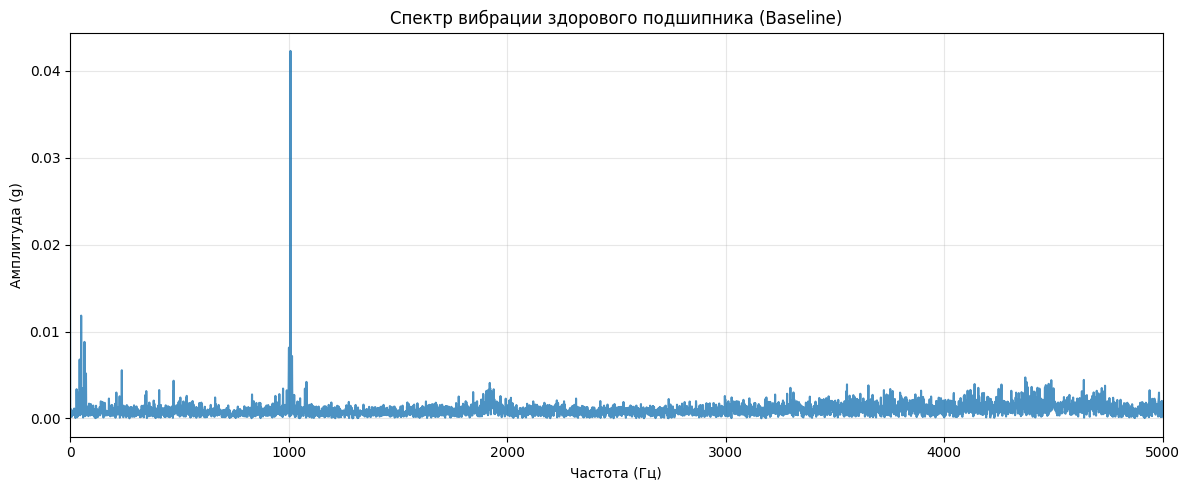

In [7]:
# Извлекаем сигнал первого подшипника из тестового сэмпла
sig = df_sample['B1'].values
fs = 20480  # Частота дискретизации (Гц)
n = len(sig)

# Вычисляем FFT
yf_raw = fft(sig)
xf_raw = fftfreq(n, 1/fs)

# Оставляем только положительные частоты и нормируем амплитуду
xf = xf_raw[:n//2]
yf = 2.0/n * np.abs(yf_raw[:n//2])

# Визуализация базового спектра
plt.figure(figsize=(12, 5))
plt.plot(xf, yf, color='tab:blue', alpha=0.8) # Синий цвет ассоциируется с "нормой"
plt.title('Спектр вибрации здорового подшипника (Baseline)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (g)')
plt.xlim(0, 5000) # Ограничиваем до 5 кГц (наиболее информативная зона)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Feature Engineering Pipeline

In [8]:
# ============================================================
# 3. FEATURE ENGINEERING: Извлечение признаков деградации
# ============================================================

def extract_time_features(signal: np.ndarray) -> dict:
    """
    Временные признаки, чувствительные к износу подшипников.
    """
    signal = signal - np.mean(signal)  # Убираем DC-компоненту
    
    rms = np.sqrt(np.mean(signal**2))
    peak = np.max(np.abs(signal))
    crest_factor = peak / rms if rms > 0 else 0
    
    # Kurtosis — критически важен для ранней детекции!
    # Чувствителен к импульсным событиям (микротрещины)
    std = np.std(signal)
    kurtosis = np.mean(signal**4) / (std**4) if std > 0 else 0
    
    # Skewness — асимметрия распределения
    skewness = np.mean(signal**3) / (std**3) if std > 0 else 0
    
    # Shape Factor
    mean_abs = np.mean(np.abs(signal))
    shape_factor = rms / mean_abs if mean_abs > 0 else 0
    
    # Impulse Factor
    impulse_factor = peak / mean_abs if mean_abs > 0 else 0
    
    # Margin Factor
    root_amp = np.mean(np.sqrt(np.abs(signal)))**2
    margin_factor = peak / root_amp if root_amp > 0 else 0
    
    return {
        'rms': rms,
        'peak': peak,
        'crest_factor': crest_factor,
        'kurtosis': kurtosis,
        'skewness': skewness,
        'shape_factor': shape_factor,
        'impulse_factor': impulse_factor,
        'margin_factor': margin_factor
    }


def extract_freq_features(signal: np.ndarray, fs: float = 20000) -> dict:
    """
    Частотные признаки на основе FFT.
    Выделяем энергию в полосах, характерных для дефектов подшипников.
    """
    n = len(signal)
    yf = fft(signal)
    xf = fftfreq(n, 1/fs)
    
    # Односторонний спектр
    mask = xf >= 0
    xf = xf[mask]
    magnitude = 2.0/n * np.abs(yf[mask])
    
    # Общая спектральная энергия
    spectral_energy = np.sum(magnitude**2)
    
    # Spectral Kurtosis — чувствителен к нестационарным импульсам
    spectral_kurtosis = np.mean((magnitude - np.mean(magnitude))**4) / (np.std(magnitude)**4)
    
    # Spectral Entropy — мера "хаотичности" спектра
    # Растёт при появлении новых гармоник от дефектов
    mag_norm = magnitude / (np.sum(magnitude) + 1e-10)
    spectral_entropy = -np.sum(mag_norm * np.log(mag_norm + 1e-10))
    
    # Энергия в частотных полосах
    # Для IMS Bearing: BPFO ~236 Hz, BPFI ~297 Hz, BSF ~279 Hz
    # Учитываем гармоники до 5x
    
    def band_energy(freqs, mags, f_center, bandwidth=50):
        mask = (freqs >= f_center - bandwidth) & (freqs <= f_center + bandwidth)
        return np.sum(mags[mask]**2)
    
    # Низкочастотная зона (общая вибрация)
    e_lf = band_energy(xf, magnitude, 100, 100)
    
    # Среднечастотная зона (резонансы)
    e_mf = band_energy(xf, magnitude, 2000, 1000)
    
    # Высокочастотная зона (импульсы от дефектов)
    e_hf = band_energy(xf, magnitude, 5000, 2000)
    
    # Энергия вокруг характерных частот подшипника
    # BPFO (Ball Pass Frequency Outer race)
    e_bpfo = sum(band_energy(xf, magnitude, 236 * h, 20) for h in range(1, 6))
    
    # BPFI (Ball Pass Frequency Inner race)
    e_bpfi = sum(band_energy(xf, magnitude, 297 * h, 20) for h in range(1, 6))
    
    # Ratio: высокочастотная / низкочастотная энергия
    hf_lf_ratio = e_hf / (e_lf + 1e-10)
    
    return {
        'spectral_energy': spectral_energy,
        'spectral_kurtosis': spectral_kurtosis,
        'spectral_entropy': spectral_entropy,
        'energy_lf': e_lf,
        'energy_mf': e_mf,
        'energy_hf': e_hf,
        'energy_bpfo': e_bpfo,
        'energy_bpfi': e_bpfi,
        'hf_lf_ratio': hf_lf_ratio
    }


def extract_all_features(df: pd.DataFrame, fs: float = 20000) -> pd.DataFrame:
    """
    Извлечение всех признаков для всех подшипников.
    """
    features_list = []
    
    for bearing in BEARING_NAMES:
        signal = df[bearing].values
        time_feats = extract_time_features(signal)
        freq_feats = extract_freq_features(signal, fs)
        
        # Объединяем с префиксом
        row = {f'{bearing}_{k}': v for k, v in {**time_feats, **freq_feats}.items()}
        features_list.append(row)
    
    # Сводим в одну строку (все подшипники)
    combined = {}
    for row in features_list:
        combined.update(row)
    
    return pd.DataFrame([combined])

## 4. Построение Health Index

In [9]:
# ============================================================
# 4. HEALTH INDEX: Монотонный индикатор деградации
# ============================================================

class HealthIndexCalculator:
    """
    Расчёт Health Index на основе ансамбля признаков.
    HI нормализован: 1.0 = здоровое состояние, 0.0 = отказ.
    """
    
    def __init__(self, baseline_window: int = 50):
        """
        baseline_window: количество первых файлов для расчёта базового состояния.
        """
        self.baseline_window = baseline_window
        self.baseline_stats = None
        self.weights = None
        
    def fit_baseline(self, features_df: pd.DataFrame):
        """
        Вычисление статистик базового (здорового) состояния.
        """
        baseline = features_df.head(self.baseline_window)
        
        self.baseline_stats = {
            'mean': baseline.mean(),
            'std': baseline.std()
        }
        
        # Веса признаков на основе корреляции с временем
        # Признаки с высокой монотонностью получают больший вес
        n_samples = len(features_df)
        time_idx = np.arange(n_samples)
        
        weights = {}
        for col in features_df.columns:
            # Spearman correlation (устойчива к нелинейностям)
            corr = features_df[col].rank().corr(pd.Series(time_idx))
            weights[col] = abs(corr)
        
        # Нормализация весов
        total = sum(weights.values())
        self.weights = {k: v/total for k, v in weights.items()}
        
        print(f"✓ Baseline fitted on {self.baseline_window} samples")
        print(f"✓ Top features by weight:")
        top_feats = sorted(weights.items(), key=lambda x: x[1], reverse=True)[:10]
        for feat, w in top_feats:
            print(f"   {feat}: {w:.4f}")
    
    def calculate_hi(self, features_df: pd.DataFrame) -> pd.Series:
        """
        Расчёт Health Index для каждого timestamp.
        Использует Mahalanobis-like distance от baseline.
        """
        if self.baseline_stats is None:
            raise ValueError("Call fit_baseline() first!")
        
        hi_values = []
        
        for idx, row in features_df.iterrows():
            # Weighted deviation score
            score = 0.0
            for col in features_df.columns:
                mean = self.baseline_stats['mean'][col]
                std = self.baseline_stats['std'][col] + 1e-10
                deviation = abs(row[col] - mean) / std
                score += self.weights[col] * deviation
            
            # Преобразуем в HI: exp(-score) даёт значения в (0, 1]
            hi = np.exp(-score)
            hi_values.append(hi)
        
        return pd.Series(hi_values, index=features_df.index)
    
    def calculate_rul(self, hi_series: pd.Series, 
                      threshold: float = 0.6,
                      critical_threshold: float = 0.3) -> dict:
        """
        Оценка Remaining Useful Life на основе экстраполяции HI.
        
        Returns:
            dict с оценкой RUL в часах и флагами тревог.
        """
        hi_values = hi_series.values
        timestamps = hi_series.index
        
        # Текущий HI
        current_hi = hi_values[-1]
        
        # Время до threshold (первая тревога)
        # Линейная экстраполяция тренда
        window = min(50, len(hi_values))
        recent_hi = hi_values[-window:]
        x = np.arange(window)
        
        # Полиномиальная аппроксимация (степень 2 для учёта ускорения деградации)
        coeffs = np.polyfit(x, recent_hi, 2)
        poly = np.poly1d(coeffs)
        
        # Поиск корня: poly(t) = threshold
        roots_threshold = np.roots([coeffs[0], coeffs[1], coeffs[2] - threshold])
        roots_critical = np.roots([coeffs[0], coeffs[1], coeffs[2] - critical_threshold])
        
        # Выбираем действительный положительный корень
        def get_valid_root(roots):
            for r in roots:
                if np.isreal(r) and r.real > window - 1:
                    return r.real
            return None
        
        t_threshold = get_valid_root(roots_threshold)
        t_critical = get_valid_root(roots_critical)
        
        # Конвертация в часы (зависит от интервала между файлами)
        # Для IMS: обычно 10 минут между записями
        interval_hours = 10 / 60  # 10 минут
        
        rul_hours = None
        rul_critical_hours = None
        
        if t_threshold is not None:
            rul_hours = (t_threshold - (window - 1)) * interval_hours
        
        if t_critical is not None:
            rul_critical_hours = (t_critical - (window - 1)) * interval_hours
        
        # Флаги тревог
        alert_warning = current_hi < threshold
        alert_critical = current_hi < critical_threshold
        
        return {
            'current_hi': current_hi,
            'rul_hours': rul_hours,
            'rul_critical_hours': rul_critical_hours,
            'alert_warning': alert_warning,
            'alert_critical': alert_critical,
            'threshold': threshold,
            'critical_threshold': critical_threshold
        }

## 5. Processing Pipeline

In [10]:
# ============================================================
# 5. PROCESSING PIPELINE: Обработка всего run-to-failure
# ============================================================

def process_dataset(data_dir: Path, hi_calc: HealthIndexCalculator) -> pd.DataFrame:
    """
    Обработка всех файлов датасета с извлечением признаков и HI.
    """
    files = sorted(data_dir.glob('*'))
    print(f"📁 Found {len(files)} files in {data_dir}")
    
    all_features = []
    timestamps = []
    
    for filepath in tqdm(files, desc="Processing files"):
        # Читаем данные
        df = pd.read_csv(filepath, sep='\t', header=None, names=BEARING_NAMES)
        
        # Извлекаем признаки
        feats = extract_all_features(df)
        all_features.append(feats)
        
        # Парсим timestamp из имени файла
        ts_str = filepath.name
        timestamps.append(ts_str)
    
    # Собираем DataFrame
    features_df = pd.concat(all_features, ignore_index=True)
    features_df['timestamp'] = timestamps
    features_df['timestamp'] = pd.to_datetime(features_df['timestamp'], 
                                              format='%Y.%m.%d.%H.%M.%S')
    features_df.set_index('timestamp', inplace=True)
    
    return features_df


# ============================================================
# 6. EXECUTION: Запуск пайплайна
# ============================================================

# Инициализация
hi_calculator = HealthIndexCalculator(baseline_window=50)

# Обработка данных
print("🚀 Starting feature extraction...")
features_df = process_dataset(DATA_DIR, hi_calculator)
print(f"✓ Extracted features: {features_df.shape}")

# Fitting baseline
print("\n📊 Fitting baseline...")
hi_calculator.fit_baseline(features_df)

# Расчёт Health Index
print("\n💚 Calculating Health Index...")
hi_series = hi_calculator.calculate_hi(features_df)
features_df['health_index'] = hi_series

# Сохранение результатов
features_df.to_csv('../output/features_with_hi.csv')
print("✓ Results saved to ../output/features_with_hi.csv")

🚀 Starting feature extraction...
📁 Found 986 files in ../data/2nd_test


Processing files: 100%|█████████▉| 984/986 [00:18<00:00, 52.42it/s] 


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x93 in position 0: invalid start byte